## **Imports**

In [1]:
from itertools import combinations

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from Bio.Align import PairwiseAligner, substitution_matrices
from Bio.Data.IUPACData import protein_letters_3to1
from Bio.PDB import PDBParser, Superimposer
from adjustText import adjust_text

## **Proteins and Dictionary**

In [2]:
parser = PDBParser(QUIET=True)

betv1 = parser.get_structure("birch", "pdb_files/1BV1.pdb")
mald1 = parser.get_structure("apple", "pdb_files/5MMU.pdb")
apig1 = parser.get_structure("celery", "pdb_files/2BK0.pdb")
pruav1 = parser.get_structure("cherry", "pdb_files/1E09.pdb")
dauc1 = parser.get_structure("carrot", "pdb_files/2WQL.pdb")

proteins = [{"name": "Bet v 1", "structure": betv1, "chainId": "A"},
            {"name": "Mal d 1", "structure": mald1, "chainId": "A"},
            {"name": "Api g 1", "structure": apig1, "chainId": "A"},
            {"name": "Pru av 1", "structure": pruav1, "chainId": "A"},
            {"name": "Dau c 1", "structure": dauc1, "chainId": "A"}]

## **Pairwise Aligner**

In [3]:
#Using BLAST Convention
aligner = PairwiseAligner(substitution_matrix = substitution_matrices.load("BLOSUM62"), open_gap_score = -11, extend_gap_score = -1, mode = "global")

## **Reading**

In [4]:
def ids(structure, model_id=0):
    """Return the chain IDs in model"""
    ls = []
    for chain in structure[model_id]:
        ls.append(chain.id)
    return ls

def sep_aminos(residues):
    """Seperate amino acids"""
    amino_acid_residues = [residue for residue in residues if residue.get_id()[0] == ' ']
    return amino_acid_residues

def get_seq_and_ca(structure, chain_id, model_id=0):
    """Gives sequence of amino acids and list of CA atoms for a single chain"""
    residues = sep_aminos(structure[model_id][chain_id])
    letters = []
    list_of_CA_atoms = []

    for residue in residues:
        if "CA" in residue:
            letters.append(protein_letters_3to1[residue.get_resname().capitalize()])
            list_of_CA_atoms.append(residue["CA"])

    seq_string = "".join(letters)

    return seq_string, list_of_CA_atoms

## **Comparing**

In [5]:
def align_seq(seq1, seq2):
    """Returns the best global alignment of two sequences."""
    alignments = aligner.align(seq1, seq2)
    return alignments[0]

def pair_ca_atoms(algmt, caA, caB):
    """Walk the aligned blocks and return two equal-length lists of paired CA atoms."""
    pairedA = []
    pairedB = []

    rangeA = algmt.aligned[0]
    rangeB = algmt.aligned[1]
    zipped = zip(rangeA, rangeB)
    for ((startA, endA), (startB, endB)) in zipped:
        for i in range(endA - startA):
            a = startA + i
            b = startB + i
            pairedA.append(caA[a])
            pairedB.append(caB[b])
    return pairedA, pairedB

def pair_identicals(algmt, strucA, strucB, chainIdA, chainIdB):
    """Return (a, b) position pairs where the aligned amino acids are identical."""
    identical_pairs = []
    seqA, caA = get_seq_and_ca(strucA, chainIdA)
    seqB, caB = get_seq_and_ca(strucB, chainIdB)
    rangeA = algmt.aligned[0]
    rangeB = algmt.aligned[1]
    zipped = zip(rangeA, rangeB)
    for ((startA, endA), (startB, endB)) in zipped:
        for i in range(endA - startA):
            a = startA + i
            b = startB + i
            if seqA[a] == seqB[b]:
                identical_pairs.append((a, b))
    return identical_pairs

def percent_identity(algmt, strucA, strucB, chainIdA, chainIdB):
    """Identical aligned pairs as a percent of the shorter sequence."""
    identical_pair_count = len(pair_identicals(algmt, strucA, strucB, chainIdA, chainIdB))
    seqA, caA = get_seq_and_ca(strucA, chainIdA)
    seqB, caB = get_seq_and_ca(strucB, chainIdB)
    shorterSeq = min(len(seqA), len(seqB))
    percent = identical_pair_count * 100 / shorterSeq
    return round(percent, 1)

def compute_rmsd(pairedA, pairedB):
    """Superimpose two paired CA atom lists and return the RMSD in Å."""
    rmsd_imposer = Superimposer()
    rmsd_imposer.set_atoms(pairedA, pairedB)
    return round(rmsd_imposer.rms, 2)

## **Data Table**

In [6]:
def allergen_comparison(proteinList):
    """Compare every unique pair of proteins; return one row per pair."""
    compareTable = []
    for p1, p2 in combinations(proteinList, 2):
        structure1 = p1["structure"]
        structure2 = p2["structure"]
        seq1, ca1 = get_seq_and_ca(structure1, p1["chainId"])
        seq2, ca2 = get_seq_and_ca(structure2, p2["chainId"])
        aligned = align_seq(seq1, seq2)
        paired1, paired2 = pair_ca_atoms(aligned, ca1, ca2)
        compareTable.append({
            "protein_a": p1["name"],
            "source_a": structure1.id,
            "protein_b": p2["name"],
            "source_b": structure2.id,
            "seq_identity_pct": percent_identity(aligned, structure1, structure2, p1["chainId"], p2["chainId"]),
            "rmsd_angstrom": compute_rmsd(paired1, paired2),
            "residues_aligned": len(paired1)
        })
    return pd.DataFrame(compareTable)

## **Save**

In [7]:
comparison = allergen_comparison(proteins)
#comparison.to_csv("comparison_df.csv", index=False)
comparison

,protein_a,source_a,protein_b,source_b,seq_identity_pct,rmsd_angstrom,residues_aligned
0,Bet v 1,birch,Mal d 1,apple,56.3,2.11,158
1,Bet v 1,birch,Api g 1,celery,42.5,1.49,153
2,Bet v 1,birch,Pru av 1,cherry,59.1,2.00,159
3,Bet v 1,birch,Dau c 1,carrot,37.5,1.61,152
4,Mal d 1,apple,Api g 1,celery,39.2,2.64,152
5,Mal d 1,apple,Pru av 1,cherry,84.8,2.11,158
6,Mal d 1,apple,Dau c 1,carrot,36.8,2.60,151
7,Api g 1,celery,Pru av 1,cherry,41.8,2.29,153
8,Api g 1,celery,Dau c 1,carrot,80.3,0.69,152
9,Pru av 1,cherry,Dau c 1,carrot,38.8,2.44,152


## **Processing**

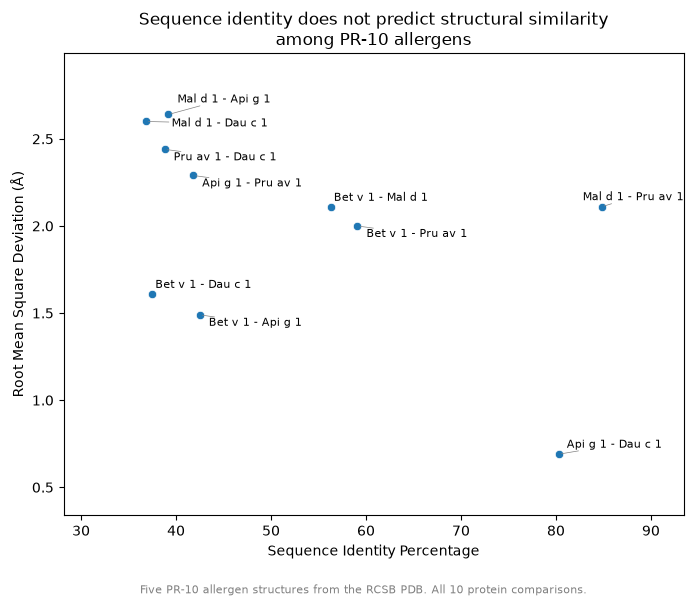

In [17]:
comparison_df = pd.read_csv("allergen_comparison.csv")
comparison_df[comparison_df["protein_a"] == "Bet v 1"]
comparison_df.sort_values(by="rmsd_angstrom", ascending=True)
plt.figure(figsize=(8,6))
plt.margins(0.18)
sip_rmsd = sns.scatterplot(data=comparison_df, x="seq_identity_pct", y="rmsd_angstrom")
sip_rmsd.set_xlabel("Sequence Identity Percentage")
sip_rmsd.set_ylabel("Root Mean Square Deviation (Å)")
sip_rmsd.set_title("Sequence identity does not predict structural similarity\namong PR-10 allergens")
plt.figtext(0.5, -0.02, "Five PR-10 allergen structures from the RCSB PDB. All 10 protein comparisons.", ha="center", fontsize=8, color="grey")
labels = []
for index, row in comparison_df.iterrows():
    labels.append(plt.text(row["seq_identity_pct"], row["rmsd_angstrom"], row["protein_a"]+" - "+row["protein_b"], fontsize=8))
adjust_text(labels, expand=(1.3, 1.5), arrowprops=dict(arrowstyle="-", lw=0.5, color="grey"))
plt.savefig("identity_vs_rmsd.png", dpi=200, bbox_inches="tight")